# Importing Libraries

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("Step 1 complete: Libraries Imported Successfully!")

Step 1 complete: Libraries Imported Successfully!


# Loading the data

In [47]:
df = pd.read_csv("Online Retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


# Exploring the data

In [48]:
# Getting the number of rows and columns
df.shape
print(f"Rows: {df.shape[0]} and Columns: {df.shape[1]}")

Rows: 541909 and Columns: 8


In [49]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [50]:
print("Column Types:")
df.dtypes

Column Types:


InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [51]:
print("Missing Values per Column:")
df.isnull().sum()

Missing Values per Column:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [52]:
print("Basic Statistics:")
df.describe().round(2)

Basic Statistics:


,Quantity,UnitPrice,CustomerID
count,541909.00,541909.00,406829.00
mean,9.55,4.61,15287.69
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


# Cleaning the Data

In [53]:
df.dropna(subset=['CustomerID'], inplace=True)
print(f"Rows after removing missing CustomerID: {len(df)}")

Rows after removing missing CustomerID: 406829


In [54]:
df['CustomerID'] = df['CustomerID'].astype(int)
print("Converted CustomerID from float to integer")

Converted CustomerID from float to integer


In [55]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],dayfirst=True)

# Handling Negative Values

In [59]:
df = df[df['Quantity'] > 0]


In [60]:
df = df[df['UnitPrice'] > 0]

In [61]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [62]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Checking Duplicates

In [64]:
df.duplicated().sum()

np.int64(5192)

In [65]:
df.drop_duplicates(inplace=True)

# Building RFM Features

In [66]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


# Scaling

In [67]:
scaler = StandardScaler()

# Apply scaling to the 3 RFM columns
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# See the result
print("Before scaling:")
print(rfm[['Recency', 'Frequency', 'Monetary']].head())

print("\nAfter scaling:")
print(rfm_scaled[:5].round(3))

Before scaling:
   Recency  Frequency  Monetary
0      326          1  77183.60
1        2          7   4310.00
2       75          4   1797.24
3       19          1   1757.55
4      310          1    334.40

After scaling:
[[ 2.335 -0.425  8.363]
 [-0.905  0.354  0.252]
 [-0.175 -0.035 -0.028]
 [-0.735 -0.425 -0.032]
 [ 2.175 -0.425 -0.191]]


# Finding best K

## Elbow Method

k=2  →  Inertia: 9014.57
k=3  →  Inertia: 5441.32
k=4  →  Inertia: 4096.30
k=5  →  Inertia: 3119.79
k=6  →  Inertia: 2473.79
k=7  →  Inertia: 2023.59
k=8  →  Inertia: 1717.01
k=9  →  Inertia: 1468.79
k=10  →  Inertia: 1281.05


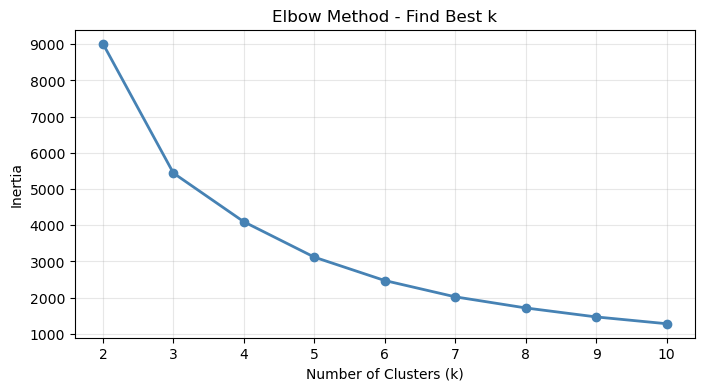

In [68]:
inertia_values = []  # empty list to store inertia for each k

# Test k = 2, 3, 4 ... 10
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia_values.append(km.inertia_)
    print(f"k={k}  →  Inertia: {km.inertia_:.2f}")

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), inertia_values, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method - Find Best k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

**The elbow is at k=4 — because:**

**From k=2 to k=4 the drop is big (good improvement)**
**From k=4 onwards the drop becomes small (not much improvement)**

**So 4 clusters is likely the best choice for your data! ✅**

# Silhouette Score


k=2  →  Silhouette Score: 0.8958
k=3  →  Silhouette Score: 0.5942
k=4  →  Silhouette Score: 0.6162
k=5  →  Silhouette Score: 0.6165
k=6  →  Silhouette Score: 0.5983
k=7  →  Silhouette Score: 0.5165
k=8  →  Silhouette Score: 0.4859
k=9  →  Silhouette Score: 0.4784
k=10  →  Silhouette Score: 0.4792


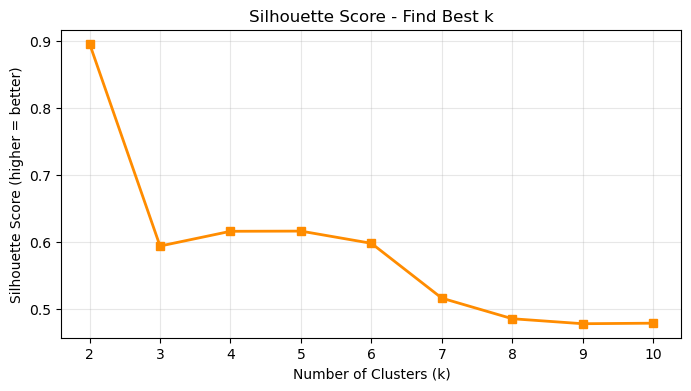

In [70]:
silhouette_scores = []  # empty list to store scores

# Test k = 2, 3, 4 ... 10
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}  →  Silhouette Score: {score:.4f}")

# Plot the Silhouette Scores
plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), silhouette_scores, marker='s', color='darkorange', linewidth=2)
plt.title('Silhouette Score - Find Best k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score (higher = better)')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

**Usually, where K is highest that point is best but in this scenerio 4 segments is more useful for business than just 2, so we will use k = 4**

# Training the Final K-Means Model


In [71]:
final_model = KMeans(n_clusters=4, random_state=42, n_init=10)

In [72]:
# fit_predict does 2 things at once:
# 1. Trains the model on our data
# 2. Assigns a cluster number (0, 1, 2, 3) to each customer
rfm['Cluster'] = final_model.fit_predict(rfm_scaled)

In [73]:
print("Customers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

Customers per cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [74]:
print("\nFirst 10 customers with their cluster:")
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster']].head(10))


First 10 customers with their cluster:
   CustomerID  Recency  Frequency  Monetary  Cluster
0       12346      326          1  77183.60        3
1       12347        2          7   4310.00        0
2       12348       75          4   1797.24        0
3       12349       19          1   1757.55        0
4       12350      310          1    334.40        1
5       12352       36          8   2506.04        0
6       12353      204          1     89.00        1
7       12354      232          1   1079.40        1
8       12355      214          1    459.40        1
9       12356       23          3   2811.43        0


# Cluster Profiling

In [75]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

print("Average RFM values per cluster:")
print(cluster_profile)

Average RFM values per cluster:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1353.63
1         248.08       1.55     478.85
2           7.38      82.54  127187.96
3          15.50      22.33   12690.50


In [76]:
def label_cluster(row):
    if row['Recency'] < cluster_profile['Recency'].median() and \
       row['Monetary'] > cluster_profile['Monetary'].median():
        return 'Champions'
    elif row['Recency'] < cluster_profile['Recency'].median():
        return 'Recent Customers'
    elif row['Monetary'] > cluster_profile['Monetary'].median():
        return 'High Spenders'
    else:
        return 'At-Risk / Inactive'

In [77]:
# Apply labels to each cluster
cluster_profile['Segment'] = cluster_profile.apply(label_cluster, axis=1)
rfm['Segment'] = rfm['Cluster'].map(cluster_profile['Segment'].to_dict())

print("\nCluster Labels:")
print(cluster_profile)

print("\nFirst 10 customers with segment:")
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head(10))


Cluster Labels:
         Recency  Frequency   Monetary             Segment
Cluster                                                   
0          43.70       3.68    1353.63  At-Risk / Inactive
1         248.08       1.55     478.85  At-Risk / Inactive
2           7.38      82.54  127187.96           Champions
3          15.50      22.33   12690.50           Champions

First 10 customers with segment:
   CustomerID  Recency  Frequency  Monetary  Cluster             Segment
0       12346      326          1  77183.60        3           Champions
1       12347        2          7   4310.00        0  At-Risk / Inactive
2       12348       75          4   1797.24        0  At-Risk / Inactive
3       12349       19          1   1757.55        0  At-Risk / Inactive
4       12350      310          1    334.40        1  At-Risk / Inactive
5       12352       36          8   2506.04        0  At-Risk / Inactive
6       12353      204          1     89.00        1  At-Risk / Inactive
7       123

# Visualization

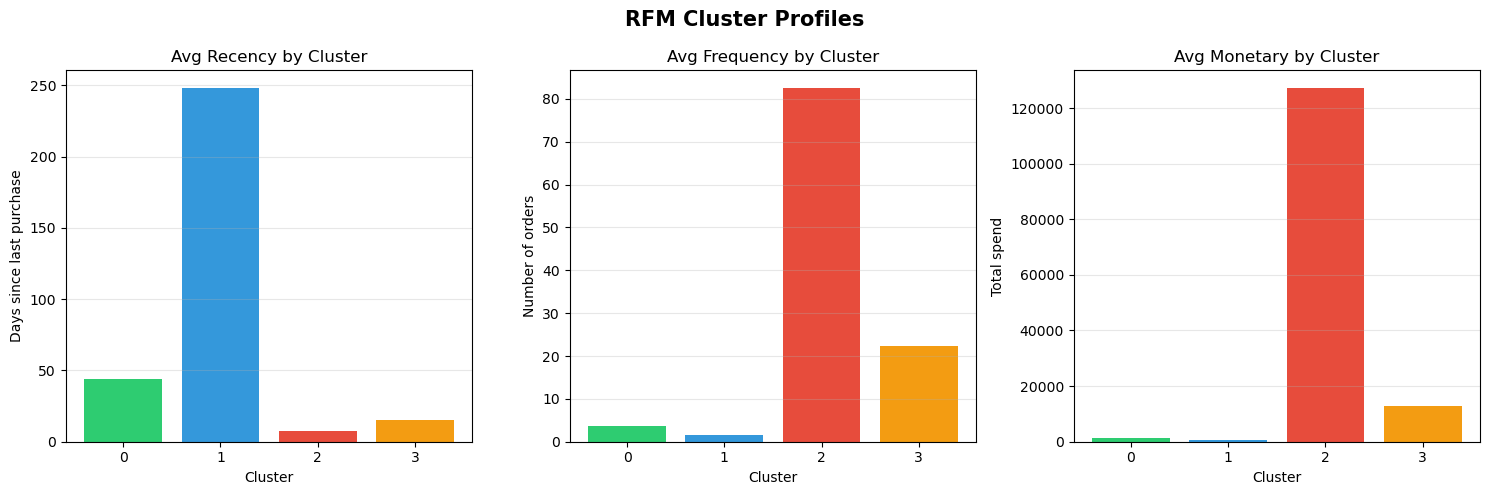

In [78]:
# STEP 11: Visualize Cluster Profiles

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

# Chart 1: Recency
axes[0].bar(cluster_profile.index.astype(str), cluster_profile['Recency'], color=colors)
axes[0].set_title('Avg Recency by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Days since last purchase')
axes[0].grid(axis='y', alpha=0.3)

# Chart 2: Frequency
axes[1].bar(cluster_profile.index.astype(str), cluster_profile['Frequency'], color=colors)
axes[1].set_title('Avg Frequency by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of orders')
axes[1].grid(axis='y', alpha=0.3)

# Chart 3: Monetary
axes[2].bar(cluster_profile.index.astype(str), cluster_profile['Monetary'], color=colors)
axes[2].set_title('Avg Monetary by Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Total spend')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('RFM Cluster Profiles', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# PCA Cluster Plot

Information kept after PCA: 85.7%


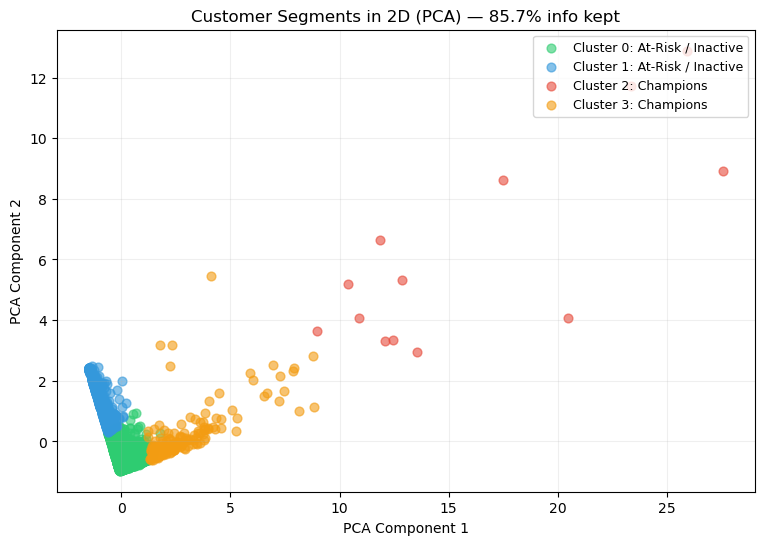

In [83]:
# PCA reduces 3 columns (R, F, M) down to 2 columns
# so we can plot it on a simple X and Y chart
pca = PCA(n_components=2, random_state=42)
rfm_2d = pca.fit_transform(rfm_scaled)

# How much original information is kept?
variance = pca.explained_variance_ratio_.sum() * 100
print(f"Information kept after PCA: {variance:.1f}%")

# Plot the clusters
plt.figure(figsize=(9, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for cluster in range(4):
    mask = rfm['Cluster'] == cluster
    segment_name = rfm[rfm['Cluster'] == cluster]['Segment'].values[0]
    plt.scatter(
        rfm_2d[mask, 0],
        rfm_2d[mask, 1],
        c=colors[cluster],
        label=f"Cluster {cluster}: {segment_name}",
        alpha=0.6,
        s=40
    )

plt.title(f'Customer Segments in 2D (PCA) — {variance:.1f}% info kept')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.2)
plt.show()

# Pie Chart - How many customers in each segment?


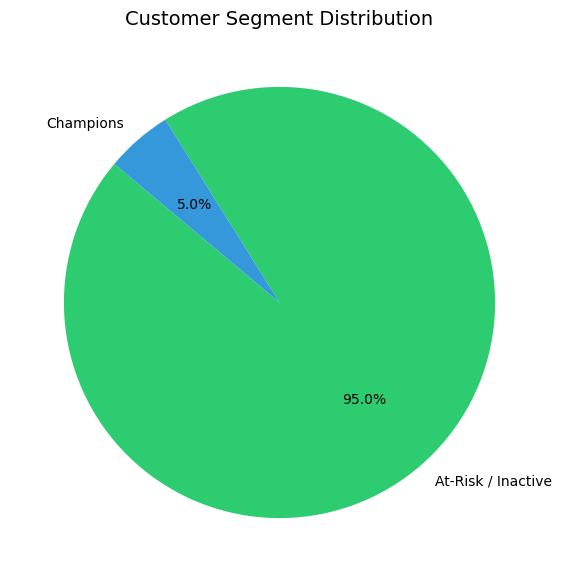

Customer count per segment:
  At-Risk / Inactive     4121 customers (95.0%)
  Champions              217 customers (5.0%)


In [81]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

plt.pie(
    segment_counts,          # values
    labels=segment_counts.index,   # segment names
    autopct='%1.1f%%',       # show percentage on each slice
    startangle=140,          # rotate starting point
    colors=colors
)

plt.title('Customer Segment Distribution', fontsize=14)
plt.show()

# Also print the numbers
print("Customer count per segment:")
for seg, count in segment_counts.items():
    pct = count / len(rfm) * 100
    print(f"  {seg:<22} {count} customers ({pct:.1f}%)")

# Saving results to CSV

In [84]:
# Select the important columns to save
output = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']]

# Save to a CSV file
output.to_csv('customer_segments_output.csv', index=False)

print("File saved successfully!")
print(f"Total customers saved: {len(output)}")
print("\nFirst 10 rows of saved file:")
print(output.head(10))

File saved successfully!
Total customers saved: 4338

First 10 rows of saved file:
   CustomerID  Recency  Frequency  Monetary  Cluster             Segment
0       12346      326          1  77183.60        3           Champions
1       12347        2          7   4310.00        0  At-Risk / Inactive
2       12348       75          4   1797.24        0  At-Risk / Inactive
3       12349       19          1   1757.55        0  At-Risk / Inactive
4       12350      310          1    334.40        1  At-Risk / Inactive
5       12352       36          8   2506.04        0  At-Risk / Inactive
6       12353      204          1     89.00        1  At-Risk / Inactive
7       12354      232          1   1079.40        1  At-Risk / Inactive
8       12355      214          1    459.40        1  At-Risk / Inactive
9       12356       23          3   2811.43        0  At-Risk / Inactive


**“Customer segmentation revealed that ~95% of customers are inactive, while a small segment (~5%) drives high revenue. PCA visualization confirmed clear cluster separation (85.7% variance retained). Insights suggest focusing on retention of high-value customers and re-engagement strategies for inactive segments.”**

**Few customers = most revenue, majority = inactive → business ko retention improve karna hoga**